In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [3]:
x=np.array([
    [10,3],
    [20,5],
    [35,20],
    [50,10]
])
y=np.array([0,0,1,1])


In [4]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

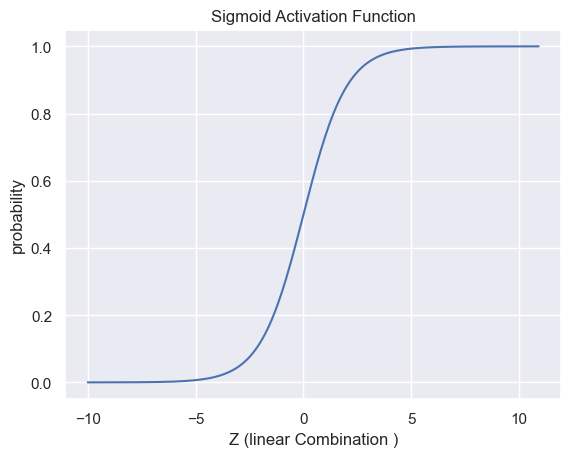

In [5]:
z=np.arange(-10,11,0.1)
sigmoid_values=sigmoid(z)

plt.plot(z,sigmoid_values)
plt.title("Sigmoid Activation Function")
plt.xlabel("Z (linear Combination )")
plt.ylabel("probability")
plt.grid(True)

In [6]:
w_init=np.array([0.5,-2])
b_init=0.01

def make_prediction(x,w,b,threshold=0.5):
    m=x.shape[0]
    pro_list=np.zeros((m,))
    
    for i in range(m):
        z=np.dot(w,x[i])+b
        prob_list=sigmoid(z)
        
    prediction=(prob_list>threshold)
    return  prediction
print("Initial Prediction:",make_prediction(x,w_init,b_init))

Initial Prediction: True


In [7]:
def compute_cost(x,y,w,b):
    m=x.shape[0]
    total_cst=0
    for i in range(m):
        z=np.dot(w,x[i])+b
        prob=sigmoid(z)
        total_cst += -y[i]*np.log(prob) - (1-y[i])*np.log(1-prob)
    return total_cst/(-m)
print("Initial Cost:",compute_cost(x,y,w_init,b_init))

Initial Cost: -5.877692344856914


In [8]:
def calculate_gradient(x,y,w,b):
    m,n=x.shape
    dw=np.zeros((n,))
    db=0
    
    for i in range(m):
        z=np.dot(w,x[i])+b
        prob=sigmoid(z)
        
        dw += (prob-y[i])*x[i]
        db += (prob-y[i])
    
    dw /= m
    db /= m
    
    return dw,db

In [ ]:
def  gradient_descent(x,y,w,b,learning_rate=0.01,num_iterations=1000):
    cost_history=[]
    
    for i in range(num_iterations):
        dw,db=calculate_gradient(x,y,w,b)
        
        w -= learning_rate*dw
        b -= learning_rate*db
        
        cost=compute_cost(x,y,w,b)
        cost_history.append(cost)
        
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost}")
    
    return w,b,cost_history

In [13]:
n=x.shape[1]
w_init=np.zeros((n,))
b_init=0.0
w_final, b_final, cost_history = gradient_descent(x,y,w_init,b_init,learning_rate=0.01,num_iterations=1000)

Iteration 0: Cost -0.7342429424562245
Iteration 100: Cost -0.5275184982127281
Iteration 200: Cost -0.4927671457944549
Iteration 300: Cost -0.4614204430226696
Iteration 400: Cost -0.43304742346349645
Iteration 500: Cost -0.40734493285059103
Iteration 600: Cost -0.3840325228076539
Iteration 700: Cost -0.36285432218776614
Iteration 800: Cost -0.3435794111931983
Iteration 900: Cost -0.3260010762989976


In [14]:
print("Final Weights (W):", w_final)
print("Final Bias (b):", b_final)

Final Weights (W): [0.02460467 0.17451845]
Final Bias (b): -1.58164925740403


In [16]:
print("Final Model Predictions:", make_prediction(x,w_final,b_final))
print("Actual Target Labels:   ", y)

Final Model Predictions: True
Actual Target Labels:    [0 0 1 1]
